# $\text{Final Project: Salary Range Prediction Using ML}$

### $\text{Auther:}$
$\begin{aligned}
&\text{TWIZIHIRWE Benjamin} \\
\end{aligned}$

**Date:** $16 \text{ January, } 2026$  
**Institution:** $\text{ATRITEC}$

---

# Introduction

In modern tech organizations, deciding on a fair and competitive salary for new hires is a complex and important task. This process often relies on personal judgment, past experiences, or informal standards, which can result in inconsistencies, bias, and dissatisfaction among employees. As organizations grow and diversify, depending on human intuition alone becomes less efficient and more risky.

Machine learning provides a data-driven way to help with salary decisions by identifying patterns in historical employee data. Instead of trying to predict a specific salary, which may be unrealistic in real Human Resource (HR) settings, this project aims to predict salary ranges. Organizations typically use salary ranges to ensure flexibility and fairness in line with their compensation policies.

In this project, we create a supervised machine learning model to classify tech employees into appropriate salary ranges based on factors like education level, years of experience, job role, technical skills, performance indicators, and organizational factors.

The goal of this study is not only just to build an accurate predictive model, but also to show how machine learning can help support clear, consistent, and data-driven salary decisions in tech organizations. The results can help HR departments make informed compensation recommendations while reducing subjectivity and improving fairness in employee pay.

# Importing libraries


In [8]:
# Numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, recall_score, roc_curve, precision_score

# Load the Dataset

In [ ]:
# Load dataset (CSV file)
df = pd.read_csv('tech_employee_salary.csv')


# View first rows
df.head()

# Data profiling

In [ ]:
# Dataset dimensions
print('Dataset Shape:', df.shape)

# Data types and missing values
df.info()

# Summary statistics
df.describe()

## Interpretation

The dataset consists of 10,000 employee records with 18 variables.. It includes a balanced mix of numerical features (such as age, skill score, performance score, projects completed, and monthly salary) and categorical features (such as gender, education level, job role, department, employment type, and location). Most variables are complete, with only a small proportion of missing values observed in years of experience. 

The dataset shows a diverse workforce, with ages ranging from 21 to 59 years and experience from nearly 0 to 22 years. Skill and performance scores vary across the full scale, while project completion and overtime hours show moderate spread. Monthly salaries range widely, from about 75,000 to over 6.5 million, with a mean near 996,000, reflecting differences in roles, experience, and qualifications. This diversity makes the dataset suitable for training a machine learning model to classify employees into salary ranges.


# Checking missing, inconsistence & outliers

In [ ]:
# Missing values count
print(df.isnull().sum())


# Check unique values for selected categorical variables
categorical_cols = ['education_level', 'job_role', 'employment_type', 'location']


for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


# Outlier detection using boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['years_experience'])
plt.title('Outliers in Years of Experience')
plt.show()

# Interpretation 

The dataset shows several outliers in years of experience, with some employees exceeding 20 years, and 423 missing values in this column. Other features are complete, but categorical variables like `education_level` contain inconsistent labels that require standardization. Job roles, employment types, and locations are well-represented, providing diversity for modeling. Overall, the data is suitable for salary range prediction after addressing missing values, outliers, and categorical inconsistencies.

# Data Cleaning Steps

The dataset was cleaned by addressing missing values, standardizing text, and handling outliers. Numerical missing values in years_experience and performance_score were imputed with the median, while categorical missing values were filled with the mode. The education_level column was standardized by removing extra spaces, converting text to lowercase, and replacing abbreviations like “BSc,” “MSc,” and “Ph.D” with “bachelor,” “master,” and “phd.” Additionally, outliers in years_experience were capped at 16 to reduce their impact on analysis.


In [ ]:
# Handle missing values
numerical_cols = ['years_experience', 'performance_score']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)


# Handle missing categorical values using mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Standardize education level text
df['education_level'] = df['education_level'].str.strip().str.lower()
df['education_level'] = df['education_level'].replace({
'bsc': 'bachelor',
'msc': 'master',
'ph.d': 'phd'
})

# Cap outliers in years of experience
df['years_experience'] = np.where(df['years_experience'] > 16, 16, df['years_experience'])

# Re-checking the missing, inconsistance and outliers

In [ ]:
# Missing values count
print(df.isnull().sum())


# Check unique values for selected categorical variables
categorical_cols = ['education_level', 'job_role', 'employment_type', 'location']

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())

# Outlier detection using boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['years_experience'])
plt.title('Outliers in Years of Experience')
plt.show()

# Creating Salary Categories 

In [14]:
# Create salary ranges
bins = [0, 500000, 900000, np.inf]
labels = ['Low', 'Medium', 'High']


df['salary_range'] = pd.cut(df['monthly_salary'], bins=bins, labels=labels)

# EXPLORATORY DATA ANALYSIS (EDA)

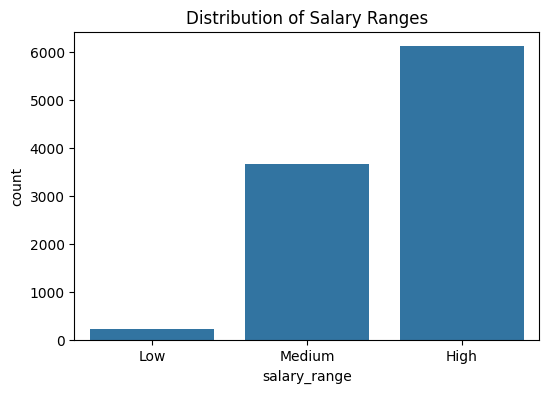

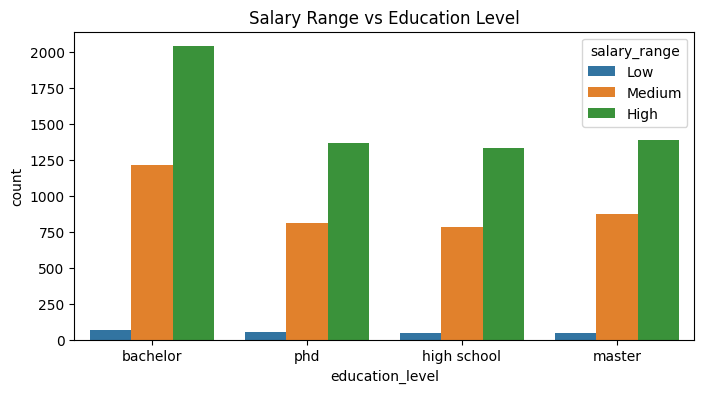

In [15]:
# Distribution of salary ranges
plt.figure(figsize=(6,4))
sns.countplot(x='salary_range', data=df)
plt.title('Distribution of Salary Ranges')
plt.show()


# Salary range vs education level
plt.figure(figsize=(8,4))
sns.countplot(x='education_level', hue='salary_range', data=df)
plt.title('Salary Range vs Education Level')
plt.show()

# Interpretation
`1. Distribution of Salary Ranges` 
* The chart shows that the dataset is heavily skewed toward the "High" salary range, with over 6,000 entries. "Medium" salaries account for roughly 3,700 entries, while "Low" salaries are the least common, representing only a few hundred individuals. This suggests that the company pay good.

`2. Salary Range vs. Education Level`
* The second chart examines salary ranges across education levels. Across all levels—Bachelor’s, Master’s, PhD, and High School—high salaries remain the most frequent, followed by medium and low. Bachelor’s holders are the largest group of high earners, while Master’s and PhD distributions are similar. Even High School graduates show a strong presence in the high-income category, indicating the dataset likely represents a high-earning niche.

#   MACHINE LEARNING


# Separate Dependent and Independent Variables

In [16]:
X = df.drop(columns=['salary_range', 'monthly_salary'])   # Independent variables
y = df['salary_range']                                    # Dependent variable


# Separate Numerical and Categorical Variables

In [17]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include='object').columns

# Feature Transformation

Numerical Variables → Scaling, 
Normalization, 
Categorical Variables → Dummies (One-Hot Encoding)

Using ColumnTransformer (Handles Everything)


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)


# Train–Test Split (Stratified)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Model Selection


In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(max_depth=7,random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(max_depth=3, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

# Evaluation Loop (Multiclass-Safe)

In [ ]:
results = []

for name, model in models.items():
    # Create a pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)

    
    
    # Metrics (multiclass-safe)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # ROC-AUC (multiclass, only if model supports predict_proba)
    if hasattr(model, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    else:
        roc_auc = None
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-score', ascending=False)
print(results_df)


# Observations:

Best overall model:` Gradient Boosting`, highest F1-score (0.8138) and very high ROC-AUC (0.9095).
`Logistic Regression` is close behind in all metrics.
`KNN` performs the worst across all metrics.
`Decision Tree` and `Random Forest` have decent accuracy but slightly lower precision/F1, which could mean they misclassify some classes more often.

Key takeaway: `Gradient Boosting` or `Logistic Regression` are your best options here.

## PREDICTING A NEW WORKER IN OUR COMPANY

The `predict_salary_range` function below predicts the salary category for a new worker using a pre-trained machine learning model and a fitted preprocessor. It converts the input worker data, provided as a dictionary, into a DataFrame that matches the structure of the training data. The preprocessor is then applied to standardize numeric features and one-hot encode categorical features. Finally, the function uses the trained model to predict the salary range and returns both the predicted class and the probabilities for each salary category, providing both the prediction and its confidence.

In [26]:
def predict_salary_range(new_worker_dict, model, preprocessor, num_cols, cat_cols):
    """
    Predict the salary range for a new worker using a trained model and preprocessor.
    Handles type consistency for numeric and categorical columns.
    """
    # Convert dictionary to DataFrame
    new_worker_df = pd.DataFrame([new_worker_dict])

    # Standardize education level text
    if 'education_level' in new_worker_df.columns:
        new_worker_df['education_level'] = new_worker_df['education_level'].str.strip().str.lower()
        new_worker_df['education_level'] = new_worker_df['education_level'].replace({
            'bsc': 'bachelor',
            'msc': 'master',
            'ph.d': 'phd'
        })

    # Ensure numeric columns are float
    for col in num_cols:
        new_worker_df[col] = new_worker_df[col].astype(float)

    # Ensure categorical columns are string
    for col in cat_cols:
        new_worker_df[col] = new_worker_df[col].astype(str)

    # Transform and predict
    X_new_transformed = preprocessor.transform(new_worker_df)
    predicted_range = model.predict(X_new_transformed)[0]
    probabilities = model.predict_proba(X_new_transformed)[0]

    return predicted_range, probabilities


`EXAMPLE`

In [ ]:
# Define new worker
new_worker = {
    'age': 28,
    'gender': 'male',
    'marital_status': 'single',
    'education_level': 'master',
    'years_experience': 5,
    'skill_score': 85,
    'certifications': 2,
    'job_role': 'analyst',
    'department': 'IT',
    'job_level': 2,
    'employment_type': 'full-time',
    'remote_status': 'on-site',
    'performance_score': 90,
    'projects_completed': 3,
    'overtime_hours': 10,
    'company_size': 'medium',
    'location': 'Kigali'
}

# Predict using the function
predicted_range, probabilities = predict_salary_range(new_worker, models['Gradient Boosting'], preprocessor, num_cols, cat_cols)

print("Predicted Salary Range:", predicted_range)
print("Prediction Probabilities:", probabilities)



# Interpretation

The model predicts the new worker belongs to the “High” salary range with high confidence (~89.5%), indicating their profile closely matches characteristics of top earners in the dataset.

                                              `END`                                                                     